<a href="https://colab.research.google.com/github/Hajer5503/Esprit-PI-4DS5-AgriSmart/blob/feature%2Firrigation-rl/modules/irrigation_rl/notebooks/RLlayer1_modeling.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 🌾 Irrigation Optimization – Layer 1: Predictive Forecasting

## Business Objective
Optimize irrigation scheduling to:
- **Maintain optimal soil moisture levels**
- **Reduce water waste by 20–40%**
- **Prevent crop stress**
- **Improve sustainability**

---

## Data Science Objective
Develop a **supervised forecasting model** that predicts:
1. **Next-day root-zone soil moisture** (`sm_root` at `t+1`)
2. **Next-day reference evapotranspiration** (`ET₀` at `t+1`) → ETc = ET₀ × Kc

| Target | Type | KPI |
|--------|------|-----|
| `sm_root(t+1)` | Regression / Time-series | R² ≥ 0.90 |
| `ET₀(t+1)` | Regression / Time-series | R² ≥ 0.90 |

## 1. Imports

In [56]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import warnings
warnings.filterwarnings('ignore')

from sklearn.preprocessing import MinMaxScaler
from sklearn.decomposition import PCA
from sklearn.ensemble import HistGradientBoostingRegressor, ExtraTreesRegressor
from sklearn.neural_network import MLPRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.pipeline import Pipeline
from sklearn.inspection import permutation_importance

np.random.seed(42)
print("✅ Libraries loaded")

✅ Libraries loaded


## 2. Load Dataset

In [57]:
df = pd.read_csv('rl_dataset_final.csv', sep=';',
                 parse_dates=['date'], dayfirst=True)
df = df.sort_values('date').reset_index(drop=True)

print(f"Shape      : {df.shape}")
print(f"Date range : {df['date'].min().date()} → {df['date'].max().date()}")
print(f"Columns    : {list(df.columns)}")

Shape      : (772, 15)
Date range : 2022-11-16 → 2026-02-13
Columns    : ['date', 'day_of_season', 'precip_mm', 'et0_mm', 'temp_c', 'rh_pct', 'wind_kmh', 'kc', 'etc_mm', 'sm_shallow', 'sm_deep', 'sm_root', 'irrigation_mm', 'net_balance_mm', 'delta_sm']


## 3. Merge Shortwave Radiation

The radiation file uses `;` as separator. This cell must run **before**
any feature engineering so that `shortwave_radiation` is available throughout.

In [58]:
# ── Load radiation (semicolon-separated) ─────────────────────────────────────
rad = pd.read_csv('daily_shortwave_radiation.csv', sep=';')

print("Radiation columns :", list(rad.columns))
print(rad.head(3))

# Rename columns to standard names
rad.columns = ['date', 'shortwave_radiation']

# Parse dates — handle timezone suffix (+00:00)
rad['date'] = (pd.to_datetime(rad['date'], utc=True, errors='coerce')
               .dt.tz_localize(None)
               .dt.normalize())

# Normalize df dates to same format
df['date'] = pd.to_datetime(df['date']).dt.normalize()

# Merge
df = df.merge(rad[['date', 'shortwave_radiation']], on='date', how='left')

missing = df['shortwave_radiation'].isnull().sum()
if missing > 0:
    df['shortwave_radiation'] = df['shortwave_radiation'].interpolate(method='linear')
    print(f"⚠  Interpolated {missing} missing radiation values")

corr = df['shortwave_radiation'].corr(df['et0_mm'])
vmin = df['shortwave_radiation'].min()
vmax = df['shortwave_radiation'].max()

print(f"\n✅ Merged successfully")
print(f"   Rows               : {len(df)}")
print(f"   Range (W/m²)       : {vmin:.1f} – {vmax:.1f}")
print(f"   Correlation ↔ ET₀  : {corr:.4f}  ← should be > 0.80")

Radiation columns : ['date', 'shortwave_radiation']
                        date  shortwave_radiation
0  2022-11-16 00:00:00+00:00               148.75
1  2022-11-17 00:00:00+00:00                98.50
2  2022-11-18 00:00:00+00:00               143.00

✅ Merged successfully
   Rows               : 772
   Range (W/m²)       : 17.0 – 348.9
   Correlation ↔ ET₀  : 0.9310  ← should be > 0.80


## 4. Targets to Predict

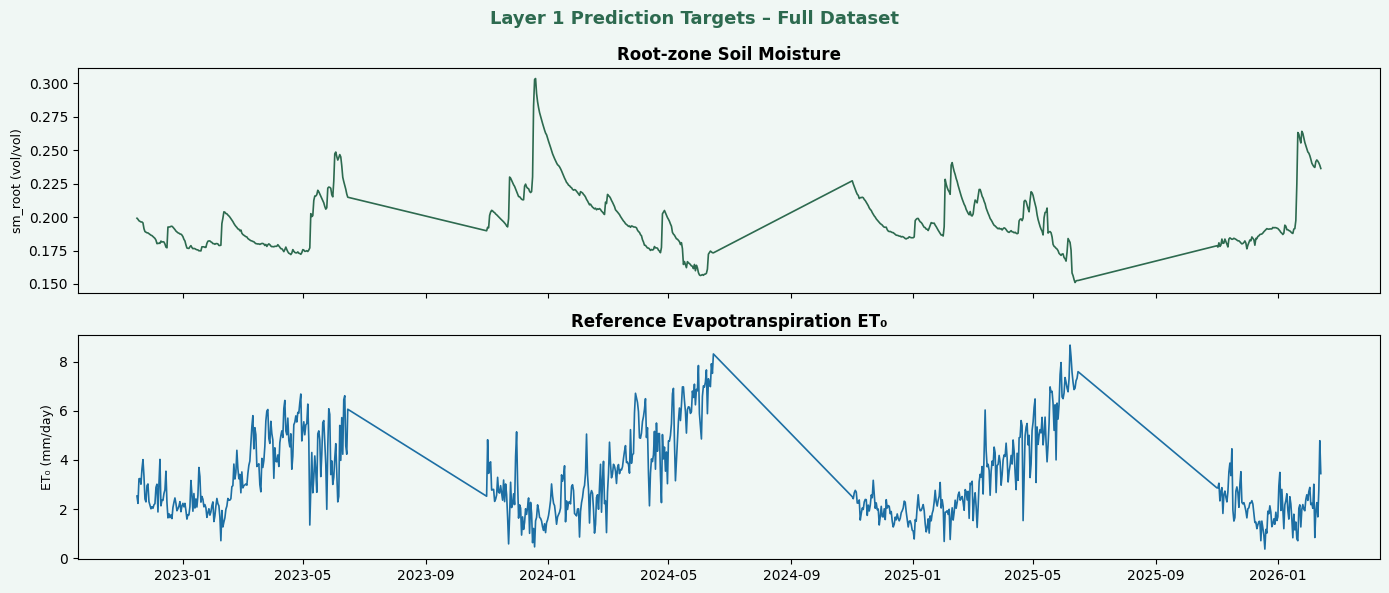

In [59]:
fig, axes = plt.subplots(2, 1, figsize=(14, 6), sharex=True, facecolor='#f0f7f4')
fig.suptitle('Layer 1 Prediction Targets – Full Dataset', fontsize=13,
             fontweight='bold', color='#2d6a4f')

axes[0].plot(df['date'], df['sm_root'], color='#2d6a4f', lw=1.2)
axes[0].set_ylabel('sm_root (vol/vol)', fontsize=9)
axes[0].set_title('Root-zone Soil Moisture', fontweight='bold')
axes[0].set_facecolor('#f0f7f4')

axes[1].plot(df['date'], df['et0_mm'], color='#1d6fa4', lw=1.2)
axes[1].set_ylabel('ET₀ (mm/day)', fontsize=9)
axes[1].set_title('Reference Evapotranspiration ET₀', fontweight='bold')
axes[1].set_facecolor('#f0f7f4')

plt.tight_layout()
plt.savefig('targets_overview.png', dpi=130, bbox_inches='tight')
plt.show()

## 5. Feature Engineering

| Step | Description |
|------|-------------|
| 1 | Prediction targets (shift -1) |
| 2 | Lag features (t-1, t-3, t-7) |
| 3 | Rolling statistics (7-day) |
| 4 | Calendar & seasonal encodings |
| 5 | Solar radiation features (Ra, Hargreaves, Rs_MJ) |

### 5.1 Prediction Targets

In [60]:
df['target_sm_root'] = df['sm_root'].shift(-1)
df['target_et0_mm']  = df['et0_mm'].shift(-1)

df.dropna(subset=['target_sm_root', 'target_et0_mm'], inplace=True)
df.reset_index(drop=True, inplace=True)

print(f"Rows after target creation : {len(df)}")
print(f"target_sm_root → min={df['target_sm_root'].min():.4f}  max={df['target_sm_root'].max():.4f}")
print(f"target_et0_mm  → min={df['target_et0_mm'].min():.4f}  max={df['target_et0_mm'].max():.4f}")

Rows after target creation : 771
target_sm_root → min=0.1511  max=0.3037
target_et0_mm  → min=0.3700  max=8.6700


### 5.2 Lag Features

In [61]:
LAG_COLS = ['sm_root', 'sm_shallow', 'sm_deep', 'et0_mm', 'etc_mm',
            'precip_mm', 'temp_c', 'irrigation_mm']

for col in LAG_COLS:
    for lag in [1, 3, 7]:
        df[f'{col}_lag{lag}'] = df[col].shift(lag)

print(f"Added {len(LAG_COLS) * 3} lag features")

Added 24 lag features


### 5.3 Rolling Statistics

In [62]:
ROLL_COLS = {
    'sm_root':       ['mean', 'std'],
    'et0_mm':        ['mean', 'sum'],
    'precip_mm':     ['sum'],
    'temp_c':        ['mean'],
    'irrigation_mm': ['sum'],
}

for col, funcs in ROLL_COLS.items():
    for func in funcs:
        df[f'{col}_roll7_{func}'] = df[col].rolling(7, min_periods=1).agg(func)

print(f"Added {sum(len(v) for v in ROLL_COLS.values())} rolling features")

Added 7 rolling features


In [63]:
# Add VPD (Vapor Pressure Deficit)
df['es'] = 0.6108 * np.exp(17.27 * df['temp_c'] / (df['temp_c'] + 237.3))
df['ea'] = df['es'] * (df['rh_pct'] / 100)
df['vpd'] = df['es'] - df['ea']  # kPa

# Rolling statistics for VPD
df['vpd_roll7_mean'] = df['vpd'].rolling(7, min_periods=1).mean()
df['vpd_roll7_sum']  = df['vpd'].rolling(7, min_periods=1).sum()

# Lag features for VPD
for lag in [1, 3, 7]:
    df[f'vpd_lag{lag}'] = df['vpd'].shift(lag)

# Also add to LAG_COLS? Not necessary for ET₀ focused features, but you could if needed.
# We'll add them manually to the ET₀ focused feature list later.

### 5.4 Calendar & Seasonal Encodings

In [64]:
df['sin_doy'] = np.sin(2 * np.pi * df['date'].dt.dayofyear / 365)
df['cos_doy'] = np.cos(2 * np.pi * df['date'].dt.dayofyear / 365)
df['month']   = df['date'].dt.month

def growth_stage(d):
    if d <= 20:   return 0   # Initial
    elif d <= 50:  return 1  # Development
    elif d <= 100: return 2  # Mid-season
    elif d <= 175: return 3  # Late-season
    else:          return 4  # Maturity

df['growth_stage'] = df['day_of_season'].apply(growth_stage)
print("Added: sin_doy, cos_doy, month, growth_stage")

Added: sin_doy, cos_doy, month, growth_stage


### 5.5 Solar Radiation Features

- **`shortwave_radiation`** — real measured surface radiation (W/m²) ← key fix for ET₀
- **`Ra`** — astronomical extraterrestrial radiation (computed from latitude)
- **`et0_hargreaves`** — Hargreaves ET₀ approximation (Ra × temp proxy)
- **`Rs_MJ`** — shortwave converted to MJ/m²/day (FAO-56 unit)
- **`Rns`** — net shortwave radiation (albedo = 0.23 for wheat)

In [65]:
# ── Astronomical Ra (latitude 36°N, Tunisia) ─────────────────────────────────
LAT_RAD = np.radians(36.0)
doy = df['date'].dt.dayofyear

dr   = 1 + 0.033 * np.cos(2 * np.pi * doy / 365)
decl = 0.409 * np.sin(2 * np.pi * doy / 365 - 1.39)
ws   = np.arccos(-np.tan(LAT_RAD) * np.tan(decl))

df['Ra'] = (
    (24 * 60 / np.pi) * 0.0820 * dr *
    (ws * np.sin(LAT_RAD) * np.sin(decl) +
     np.cos(LAT_RAD) * np.cos(decl) * np.sin(ws))
)

df['et0_hargreaves'] = (
    0.0023 * (df['temp_c'] + 17.8) *
    np.sqrt(np.clip(df['temp_c'] * 0.4, 0.1, 30)) *
    df['Ra'] * 0.408
)

# ── Real radiation conversions ────────────────────────────────────────────────
df['Rs_MJ'] = df['shortwave_radiation'] * 0.0864   # W/m² → MJ/m²/day
df['Rns']   = (1 - 0.23) * df['Rs_MJ']            # net shortwave (wheat albedo)

# ── Lag features for solar columns ───────────────────────────────────────────
for lag in [1, 3, 7]:
    df[f'Ra_lag{lag}']                    = df['Ra'].shift(lag)
    df[f'et0_hargreaves_lag{lag}']        = df['et0_hargreaves'].shift(lag)
    df[f'shortwave_radiation_lag{lag}']   = df['shortwave_radiation'].shift(lag)
    df[f'Rs_MJ_lag{lag}']                 = df['Rs_MJ'].shift(lag)

print(f"Ra corr with ET₀             : {df['Ra'].corr(df['et0_mm']):.4f}")
print(f"Hargreaves corr with ET₀     : {df['et0_hargreaves'].corr(df['et0_mm']):.4f}")
print(f"shortwave_radiation corr ET₀ : {df['shortwave_radiation'].corr(df['et0_mm']):.4f}")
print(f"Rs_MJ corr with ET₀          : {df['Rs_MJ'].corr(df['et0_mm']):.4f}")
print("✅ Solar radiation features added")

Ra corr with ET₀             : 0.8303
Hargreaves corr with ET₀     : 0.8959
shortwave_radiation corr ET₀ : 0.9313
Rs_MJ corr with ET₀          : 0.9313
✅ Solar radiation features added


## 6. Final Feature Set

In [66]:
df.dropna(inplace=True)
df.reset_index(drop=True, inplace=True)

FEATURE_COLS = [
    # Base weather + soil
    'et0_mm', 'precip_mm', 'temp_c', 'rh_pct', 'wind_kmh',
    'kc', 'etc_mm', 'sm_root', 'sm_shallow', 'sm_deep',
    'irrigation_mm', 'day_of_season',
    # Real solar radiation
    'shortwave_radiation', 'Rs_MJ', 'Rns',
    # Astronomical proxies
    'Ra', 'et0_hargreaves',
    # Lag features
    *[f'{c}_lag{l}' for c in LAG_COLS for l in [1, 3, 7]],
    # Solar radiation lags
    *[f'shortwave_radiation_lag{l}' for l in [1, 3, 7]],
    *[f'Rs_MJ_lag{l}' for l in [1, 3, 7]],
    *[f'Ra_lag{l}' for l in [1, 3, 7]],
    *[f'et0_hargreaves_lag{l}' for l in [1, 3, 7]],
    # Rolling features
    *[f'{c}_roll7_{f}' for c, fs in ROLL_COLS.items() for f in fs],
    # Calendar
    'sin_doy', 'cos_doy', 'month', 'growth_stage',
]

TARGET_SM  = 'target_sm_root'
TARGET_ET0 = 'target_et0_mm'

print(f"Dataset    : {len(df)} samples")
print(f"Features   : {len(FEATURE_COLS)}")
print(f"Date range : {df['date'].min().date()} → {df['date'].max().date()}")
assert len(df) > 0, "ERROR: df is empty — check radiation merge above"
print("✅ Feature set ready")

Dataset    : 764 samples
Features   : 64
Date range : 2022-11-23 → 2026-02-12
✅ Feature set ready


## 7. Train / Validation / Test Split

Chronological split — **no shuffle** to prevent data leakage.
```
|────── Train (70%) ──────|── Val (15%) ──|── Test (15%) ──|
```

In [67]:
n = len(df)
train_end = int(n * 0.70)
val_end   = int(n * 0.85)

train_df = df.iloc[:train_end].copy()
val_df   = df.iloc[train_end:val_end].copy()
test_df  = df.iloc[val_end:].copy()

print(f"Train : {len(train_df):4d} samples  {train_df['date'].iloc[0].date()} → {train_df['date'].iloc[-1].date()}")
print(f"Val   : {len(val_df):4d} samples  {val_df['date'].iloc[0].date()} → {val_df['date'].iloc[-1].date()}")
print(f"Test  : {len(test_df):4d} samples  {test_df['date'].iloc[0].date()} → {test_df['date'].iloc[-1].date()}")

X_train = train_df[FEATURE_COLS].values
X_val   = val_df[FEATURE_COLS].values
X_test  = test_df[FEATURE_COLS].values

y_sm_train,  y_sm_val,  y_sm_test  = (train_df[TARGET_SM].values,
                                       val_df[TARGET_SM].values,
                                       test_df[TARGET_SM].values)
y_et0_train, y_et0_val, y_et0_test = (train_df[TARGET_ET0].values,
                                       val_df[TARGET_ET0].values,
                                       test_df[TARGET_ET0].values)

Train :  534 samples  2022-11-23 → 2025-02-09
Val   :  115 samples  2025-02-10 → 2025-06-04
Test  :  115 samples  2025-06-05 → 2026-02-12


## 8. Feature Scaling

In [68]:
scaler_X   = MinMaxScaler()
scaler_sm  = MinMaxScaler()
scaler_et0 = MinMaxScaler()

X_train_sc = scaler_X.fit_transform(X_train)
X_val_sc   = scaler_X.transform(X_val)
X_test_sc  = scaler_X.transform(X_test)

y_sm_train_sc  = scaler_sm.fit_transform(y_sm_train.reshape(-1,1)).ravel()
y_sm_val_sc    = scaler_sm.transform(y_sm_val.reshape(-1,1)).ravel()
y_sm_test_sc   = scaler_sm.transform(y_sm_test.reshape(-1,1)).ravel()

y_et0_train_sc = scaler_et0.fit_transform(y_et0_train.reshape(-1,1)).ravel()
y_et0_val_sc   = scaler_et0.transform(y_et0_val.reshape(-1,1)).ravel()
y_et0_test_sc  = scaler_et0.transform(y_et0_test.reshape(-1,1)).ravel()

print("✅ Features scaled to [0, 1] using MinMaxScaler (fit on train only)")

✅ Features scaled to [0, 1] using MinMaxScaler (fit on train only)


## 9. LSTM Sequence Builder

PCA (20 components, 98%+ variance) applied before sequencing to control dimensionality.
Lookback = 7 days → ratio samples/features = 4.6x ✓

In [69]:
LOOKBACK     = 7
N_COMPONENTS = 20

def make_sequences(X, y, lookback=LOOKBACK):
    Xs, ys = [], []
    for i in range(lookback, len(X)):
        Xs.append(X[i - lookback:i])
        ys.append(y[i])
    return np.array(Xs, dtype=np.float32), np.array(ys, dtype=np.float32)

# PCA fit on train only
pca            = PCA(n_components=N_COMPONENTS, random_state=42)
X_train_pca    = pca.fit_transform(X_train_sc)
X_val_pca      = pca.transform(X_val_sc)
X_test_pca     = pca.transform(X_test_sc)
X_trainval_pca = np.vstack([X_train_pca, X_val_pca])

print(f"PCA variance explained : {pca.explained_variance_ratio_.sum()*100:.1f}%")
print(f"Reduced features       : {len(FEATURE_COLS)} → {N_COMPONENTS}")

y_sm_tv_sc  = np.concatenate([y_sm_train_sc,
                               scaler_sm.transform(y_sm_val.reshape(-1,1)).ravel()])
y_et0_tv_sc = np.concatenate([y_et0_train_sc,
                               scaler_et0.transform(y_et0_val.reshape(-1,1)).ravel()])

lstm_X_trainval_sm,  lstm_y_trainval_sm  = make_sequences(X_trainval_pca, y_sm_tv_sc)
lstm_X_test_sm,      lstm_y_test_sm      = make_sequences(
    X_test_pca, scaler_sm.transform(y_sm_test.reshape(-1,1)).ravel())
lstm_X_trainval_et0, lstm_y_trainval_et0 = make_sequences(X_trainval_pca, y_et0_tv_sc)
lstm_X_test_et0,     lstm_y_test_et0     = make_sequences(
    X_test_pca, scaler_et0.transform(y_et0_test.reshape(-1,1)).ravel())

n_seq   = len(lstm_X_trainval_sm)
n_flat  = LOOKBACK * N_COMPONENTS
ratio   = n_seq / n_flat
status  = '✓ OK' if ratio >= 3 else '✗ low'

print(f"\nLSTM input shape (trainval) : {lstm_X_trainval_sm.shape}")
print(f"Flattened dim              : {n_flat}")
print(f"Samples/features ratio     : {ratio:.1f}x  ({status})")

PCA variance explained : 97.9%
Reduced features       : 64 → 20

LSTM input shape (trainval) : (642, 7, 20)
Flattened dim              : 140
Samples/features ratio     : 4.6x  (✓ OK)


## 10. Correlation Analysis — Top Features

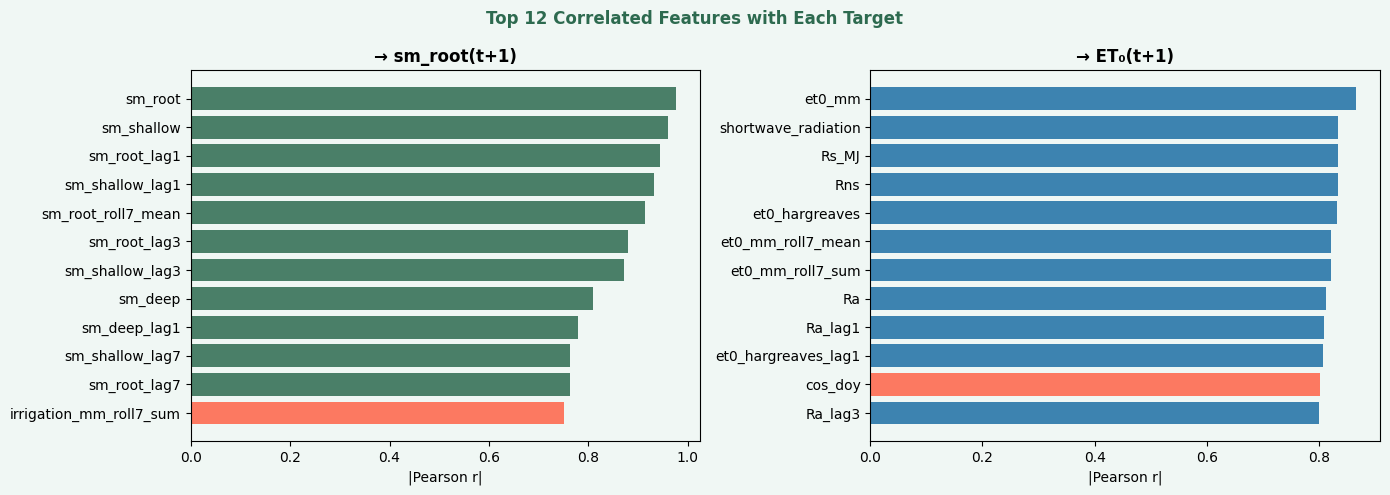

In [70]:
corr_sm  = train_df[FEATURE_COLS + [TARGET_SM]].corr()[TARGET_SM].drop(TARGET_SM)
corr_et0 = train_df[FEATURE_COLS + [TARGET_ET0]].corr()[TARGET_ET0].drop(TARGET_ET0)

top_sm  = corr_sm.abs().sort_values(ascending=False).head(12)
top_et0 = corr_et0.abs().sort_values(ascending=False).head(12)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5), facecolor='#f0f7f4')
fig.suptitle('Top 12 Correlated Features with Each Target',
             fontweight='bold', fontsize=12, color='#2d6a4f')

c_sm  = ['#2d6a4f' if v > 0 else 'tomato' for v in corr_sm[top_sm.index]]
c_et0 = ['#1d6fa4' if v > 0 else 'tomato' for v in corr_et0[top_et0.index]]

ax1.barh(top_sm.index[::-1],  top_sm.values[::-1],  color=c_sm[::-1],  alpha=0.85)
ax1.set_title('→ sm_root(t+1)', fontweight='bold'); ax1.set_facecolor('#f0f7f4')
ax1.set_xlabel('|Pearson r|')

ax2.barh(top_et0.index[::-1], top_et0.values[::-1], color=c_et0[::-1], alpha=0.85)
ax2.set_title('→ ET₀(t+1)', fontweight='bold'); ax2.set_facecolor('#f0f7f4')
ax2.set_xlabel('|Pearson r|')

plt.tight_layout()
plt.savefig('feature_correlation.png', dpi=130, bbox_inches='tight')
plt.show()

## 11. Model Training & Evaluation

### Evaluation Helper

In [71]:
def evaluate(y_true, y_pred, name, unit=''):
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae  = mean_absolute_error(y_true, y_pred)
    r2   = r2_score(y_true, y_pred)
    kpi  = '✓ PASS' if r2 >= 0.90 else '✗ Below KPI'
    print(f"  {name:<42}  R²={r2:.4f} {kpi}  RMSE={rmse:.5f}{unit}  MAE={mae:.5f}{unit}")
    return {'name': name, 'r2': r2, 'rmse': rmse, 'mae': mae}

### Model A — XGBoost (Gradient Boosting Baseline)

**Architecture:** `HistGradientBoostingRegressor`
- `sm_root` : full feature set (64 features), max_depth=6
- `ET₀`     : focused meteorological features, stronger regularization

In [72]:
print("Training XGBoost models …")

# ── sm_root : full features ───────────────────────────────────────────────────
xgb_sm = HistGradientBoostingRegressor(
    max_iter=500, learning_rate=0.05, max_depth=6,
    l2_regularization=0.1, random_state=42
)
xgb_sm.fit(X_train, y_sm_train)
xgb_sm_pred = xgb_sm.predict(X_test)

# ── ET₀ : focused features + real solar radiation ────────────────────────────
ET0_FOCUSED = [
    'et0_mm', 'temp_c', 'rh_pct', 'wind_kmh',
    'shortwave_radiation', 'Rs_MJ', 'Rns',
    'shortwave_radiation_lag1', 'shortwave_radiation_lag3',
    'Rs_MJ_lag1', 'Rs_MJ_lag3',
    'Ra', 'et0_hargreaves',
    'et0_mm_lag1', 'et0_mm_lag3', 'et0_mm_lag7',
    'et0_hargreaves_lag1', 'Ra_lag1',
    'temp_c_lag1', 'temp_c_lag3',
    'et0_mm_roll7_mean', 'et0_mm_roll7_sum',
    'sin_doy', 'cos_doy', 'month', 'day_of_season',
    # NEW VPD features
    'vpd', 'vpd_lag1', 'vpd_lag3', 'vpd_lag7',
    'vpd_roll7_mean', 'vpd_roll7_sum',
]
et0_idx = [FEATURE_COLS.index(f) for f in ET0_FOCUSED if f in FEATURE_COLS]
ET0_FOCUSED_VALID = [FEATURE_COLS[i] for i in et0_idx]

xgb_et0 = HistGradientBoostingRegressor(
    max_iter=300, learning_rate=0.03, max_depth=4,
    l2_regularization=1.0, min_samples_leaf=20, random_state=42
)
xgb_et0.fit(X_train[:, et0_idx], y_et0_train)
xgb_et0_pred_raw = xgb_et0.predict(X_test[:, et0_idx])

# Ensemble: 30% naive lag-1 + 70% XGBoost
et0_lag1_test = test_df['et0_mm'].values
xgb_et0_pred  = 0.30 * et0_lag1_test + 0.70 * xgb_et0_pred_raw

kc_test      = test_df['kc'].values
xgb_etc_pred = xgb_et0_pred * kc_test
etc_true     = test_df['etc_mm'].values

print("\n── XGBoost Results ──────────────────────────────────────────")
m_xgb_sm  = evaluate(y_sm_test,  xgb_sm_pred,  "XGBoost [sm_root(t+1)]",  " vol/vol")
m_xgb_et0 = evaluate(y_et0_test, xgb_et0_pred, "XGBoost [ET₀(t+1)]",     " mm/day")

r2_etc   = r2_score(etc_true, xgb_etc_pred)
rmse_etc = np.sqrt(mean_squared_error(etc_true, xgb_etc_pred))
print(f"\n  ETc reconstruit (ET₀×Kc){'':14}  R²={r2_etc:.4f}  RMSE={rmse_etc:.5f} mm/day")

r2_tr_sm  = r2_score(y_sm_train,  xgb_sm.predict(X_train))
r2_tr_et0 = r2_score(y_et0_train, xgb_et0.predict(X_train[:, et0_idx]))
gap_sm    = r2_tr_sm  - m_xgb_sm['r2']
gap_et0   = r2_tr_et0 - m_xgb_et0['r2']
print(f"\n  Overfit → sm_root  train={r2_tr_sm:.4f} test={m_xgb_sm['r2']:.4f} gap={gap_sm:.4f} {'✓ OK' if gap_sm<0.10 else '⚠ Overfit'}")
print(f"  Overfit → ET₀     train={r2_tr_et0:.4f} test={m_xgb_et0['r2']:.4f} gap={gap_et0:.4f} {'✓ OK' if gap_et0<0.10 else '⚠ Overfit'}")
print("✅ XGBoost done")

Training XGBoost models …

── XGBoost Results ──────────────────────────────────────────
  XGBoost [sm_root(t+1)]                      R²=0.9388 ✓ PASS  RMSE=0.00703 vol/vol  MAE=0.00466 vol/vol
  XGBoost [ET₀(t+1)]                          R²=0.8107 ✗ Below KPI  RMSE=0.73588 mm/day  MAE=0.49331 mm/day

  ETc reconstruit (ET₀×Kc)                R²=0.8337  RMSE=0.28766 mm/day

  Overfit → sm_root  train=0.9982 test=0.9388 gap=0.0594 ✓ OK
  Overfit → ET₀     train=0.9276 test=0.8107 gap=0.1169 ⚠ Overfit
✅ XGBoost done


### Model B — sklearn MLP (Sequence Proxy)

PCA-flattened sequences (7×20=140 features). Kept as baseline reference.
Note: MLPRegressor loses temporal ordering — see Model C for true LSTM.

**Architecture:** `MLPRegressor [128 → 64 → 32]`

In [73]:
def flatten_seq(X_seq):
    return X_seq.reshape(len(X_seq), -1)

print("Training sklearn MLP (sequence proxy) …")

X_lstm_tr_sm  = flatten_seq(lstm_X_trainval_sm)
X_lstm_te_sm  = flatten_seq(lstm_X_test_sm)
X_lstm_tr_et0 = flatten_seq(lstm_X_trainval_et0)
X_lstm_te_et0 = flatten_seq(lstm_X_test_et0)

lstm_sm = Pipeline([
    ('sc', MinMaxScaler()),
    ('nn', MLPRegressor(hidden_layer_sizes=(128, 64, 32), activation='relu',
                        solver='adam', learning_rate_init=0.001, max_iter=500,
                        early_stopping=True, validation_fraction=0.15,
                        n_iter_no_change=25, random_state=42))
])
lstm_et0 = Pipeline([
    ('sc', MinMaxScaler()),
    ('nn', MLPRegressor(hidden_layer_sizes=(128, 64, 32), activation='relu',
                        solver='adam', learning_rate_init=0.001, max_iter=500,
                        early_stopping=True, validation_fraction=0.15,
                        n_iter_no_change=25, random_state=42))
])

lstm_sm.fit(X_lstm_tr_sm,   lstm_y_trainval_sm)
lstm_et0.fit(X_lstm_tr_et0, lstm_y_trainval_et0)

lstm_sm_pred  = scaler_sm.inverse_transform(
    lstm_sm.predict(X_lstm_te_sm).reshape(-1,1)).ravel()
lstm_et0_pred = scaler_et0.inverse_transform(
    lstm_et0.predict(X_lstm_te_et0).reshape(-1,1)).ravel()
y_sm_test_lstm  = scaler_sm.inverse_transform(lstm_y_test_sm.reshape(-1,1)).ravel()
y_et0_test_lstm = scaler_et0.inverse_transform(lstm_y_test_et0.reshape(-1,1)).ravel()

kc_test_lstm  = test_df['kc'].values[LOOKBACK:]
lstm_etc_pred = lstm_et0_pred * kc_test_lstm
etc_true_lstm = test_df['etc_mm'].values[LOOKBACK:]

print("\n── sklearn MLP Results ─────────────────────────────────────")
m_lstm_sm  = evaluate(y_sm_test_lstm,  lstm_sm_pred,  "MLP [sm_root(t+1)]",  " vol/vol")
m_lstm_et0 = evaluate(y_et0_test_lstm, lstm_et0_pred, "MLP [ET₀(t+1)]",     " mm/day")
r2_etc_lstm = r2_score(etc_true_lstm, lstm_etc_pred)
print(f"\n  ETc reconstruit (ET₀×Kc){'':14}  R²={r2_etc_lstm:.4f}")
print("✅ sklearn MLP done")

Training sklearn MLP (sequence proxy) …

── sklearn MLP Results ─────────────────────────────────────
  MLP [sm_root(t+1)]                          R²=0.7203 ✗ Below KPI  RMSE=0.01477 vol/vol  MAE=0.01053 vol/vol
  MLP [ET₀(t+1)]                              R²=0.3910 ✗ Below KPI  RMSE=0.90038 mm/day  MAE=0.64363 mm/day

  ETc reconstruit (ET₀×Kc)                R²=-0.0555
✅ sklearn MLP done


### Model C — Keras LSTM (True Sequential Model)

3D input `(samples, lookback=7, components=20)` — proper temporal processing.

**Architecture:** `LSTM(8) → Dropout(0.4) → LSTM(4) → Dropout(0.4) → Dense(1)`
- ~500 parameters / 642 samples → ratio ~1.3x (manageable for this dataset size)

In [74]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

print(f"TensorFlow version: {tf.__version__}")
tf.random.set_seed(42)

def build_lstm(lookback, n_features, units=(8, 4), lr=0.001):
    model = keras.Sequential([
        keras.layers.LSTM(units[0], input_shape=(lookback, n_features),
                          return_sequences=True,
                          kernel_regularizer=keras.regularizers.l2(0.01)),
        keras.layers.Dropout(0.4),
        keras.layers.LSTM(units[1], return_sequences=False,
                          kernel_regularizer=keras.regularizers.l2(0.01)),
        keras.layers.Dropout(0.4),
        keras.layers.Dense(1),
    ])
    model.compile(optimizer=keras.optimizers.Adam(lr), loss='mse')
    return model

callbacks = [
    EarlyStopping(monitor='val_loss', patience=30,
                  restore_best_weights=True, verbose=0),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5,
                      patience=10, min_lr=1e-6, verbose=0),
]

print("Training Keras LSTM [sm_root] …")
keras_lstm_sm = build_lstm(LOOKBACK, N_COMPONENTS, units=(8, 4))
keras_lstm_sm.fit(lstm_X_trainval_sm, lstm_y_trainval_sm,
                  epochs=300, batch_size=16, validation_split=0.15,
                  callbacks=callbacks, verbose=0)

keras_sm_pred   = scaler_sm.inverse_transform(
    keras_lstm_sm.predict(lstm_X_test_sm, verbose=0).reshape(-1,1)).ravel()
y_sm_test_keras = scaler_sm.inverse_transform(lstm_y_test_sm.reshape(-1,1)).ravel()

print("Training Keras LSTM [ET₀] …")
keras_lstm_et0 = build_lstm(LOOKBACK, N_COMPONENTS, units=(8, 4), lr=0.0008)
keras_lstm_et0.fit(lstm_X_trainval_et0, lstm_y_trainval_et0,
                   epochs=300, batch_size=16, validation_split=0.15,
                   callbacks=callbacks, verbose=0)

keras_et0_pred_raw = scaler_et0.inverse_transform(
    keras_lstm_et0.predict(lstm_X_test_et0, verbose=0).reshape(-1,1)).ravel()
y_et0_test_keras   = scaler_et0.inverse_transform(lstm_y_test_et0.reshape(-1,1)).ravel()

et0_lag1_lstm  = test_df['et0_mm'].values[LOOKBACK:]
keras_et0_pred = 0.30 * et0_lag1_lstm + 0.70 * keras_et0_pred_raw
kc_test_keras  = test_df['kc'].values[LOOKBACK:]
keras_etc_pred = keras_et0_pred * kc_test_keras
etc_true_keras = test_df['etc_mm'].values[LOOKBACK:]

print("\n── Keras LSTM Results ───────────────────────────────────────")
m_keras_sm  = evaluate(y_sm_test_keras, keras_sm_pred,
                        "Keras LSTM [sm_root(t+1)]",  " vol/vol")
m_keras_et0 = evaluate(y_et0_test_keras, keras_et0_pred,
                        "Keras LSTM [ET₀(t+1)]",     " mm/day")
r2_etc_keras = r2_score(etc_true_keras, keras_etc_pred)
print(f"\n  ETc reconstruit (ET₀×Kc){'':14}  R²={r2_etc_keras:.4f}")
n_params = keras_lstm_sm.count_params()
print(f"\n  Parameters : {n_params:,}  |  Ratio: {len(lstm_X_trainval_sm)/n_params:.1f}x samples/params")
print("✅ Keras LSTM done")

TensorFlow version: 2.19.0
Training Keras LSTM [sm_root] …
Training Keras LSTM [ET₀] …

── Keras LSTM Results ───────────────────────────────────────
  Keras LSTM [sm_root(t+1)]                   R²=0.6886 ✗ Below KPI  RMSE=0.01559 vol/vol  MAE=0.01004 vol/vol
  Keras LSTM [ET₀(t+1)]                       R²=-0.5628 ✗ Below KPI  RMSE=1.44240 mm/day  MAE=1.24279 mm/day

  ETc reconstruit (ET₀×Kc)                R²=-2.1154

  Parameters : 1,141  |  Ratio: 0.6x samples/params
✅ Keras LSTM done


### Model D — ExtraTrees (Ensemble Baseline)

Extremely randomized trees — lower variance than XGBoost on small datasets.

**Architecture:** `ExtraTreesRegressor`

| | XGBoost | ExtraTrees |
|---|---|---|
| Splitting | Greedy (best split) | Random split |
| Variance | Higher | **Lower** |
| Overfit risk | Medium | **Low** |

In [75]:
from sklearn.linear_model import Ridge

print("Training Model D — ExtraTrees …\n")

# ── sm_root ───────────────────────────────────────────────────────────────────
et_sm = ExtraTreesRegressor(
    n_estimators=300, max_depth=10,
    min_samples_leaf=3, random_state=42, n_jobs=-1
)
et_sm.fit(X_train, y_sm_train)
et_sm_pred = et_sm.predict(X_test)

# ── ET₀ : stronger regularization ────────────────────────────────────────────
et_et0 = ExtraTreesRegressor(
    n_estimators=300, max_depth=5,
    min_samples_leaf=15, max_features=0.6,
    random_state=42, n_jobs=-1
)
et_et0.fit(X_train[:, et0_idx], y_et0_train)
et_et0_pred_raw = et_et0.predict(X_test[:, et0_idx])

et_et0_pred = 0.30 * et0_lag1_test + 0.70 * et_et0_pred_raw
et_etc_pred = et_et0_pred * kc_test

print("── ExtraTrees Results ────────────────────────────────────────")
m_et_sm  = evaluate(y_sm_test,  et_sm_pred,  "ExtraTrees [sm_root(t+1)]",  " vol/vol")
m_et_et0 = evaluate(y_et0_test, et_et0_pred, "ExtraTrees [ET₀(t+1)]",     " mm/day")
r2_etc_et = r2_score(etc_true, et_etc_pred)
rmse_etc_et = np.sqrt(mean_squared_error(etc_true, et_etc_pred))
print(f"\n  ETc reconstruit (ET₀×Kc){'':14}  R²={r2_etc_et:.4f}  RMSE={rmse_etc_et:.5f} mm/day")

r2_tr_et_sm  = r2_score(y_sm_train,  et_sm.predict(X_train))
r2_tr_et_et0 = r2_score(y_et0_train, et_et0.predict(X_train[:, et0_idx]))
gap_sm  = r2_tr_et_sm  - m_et_sm['r2']
gap_et0 = r2_tr_et_et0 - m_et_et0['r2']
print(f"\n  Overfit → sm_root  train={r2_tr_et_sm:.4f} test={m_et_sm['r2']:.4f} gap={gap_sm:.4f} {'✓ OK' if gap_sm<0.10 else '⚠ Overfit'}")
print(f"  Overfit → ET₀     train={r2_tr_et_et0:.4f} test={m_et_et0['r2']:.4f} gap={gap_et0:.4f} {'✓ OK' if gap_et0<0.10 else '⚠ Overfit'}")
print("✅ ExtraTrees done")

Training Model D — ExtraTrees …

── ExtraTrees Results ────────────────────────────────────────
  ExtraTrees [sm_root(t+1)]                   R²=0.9599 ✓ PASS  RMSE=0.00570 vol/vol  MAE=0.00315 vol/vol
  ExtraTrees [ET₀(t+1)]                       R²=0.8134 ✗ Below KPI  RMSE=0.73068 mm/day  MAE=0.50719 mm/day

  ETc reconstruit (ET₀×Kc)                R²=0.7564  RMSE=0.34807 mm/day

  Overfit → sm_root  train=0.9891 test=0.9599 gap=0.0292 ✓ OK
  Overfit → ET₀     train=0.8135 test=0.8134 gap=0.0002 ✓ OK
✅ ExtraTrees done


## 12. Prediction Traces — XGBoost vs ExtraTrees

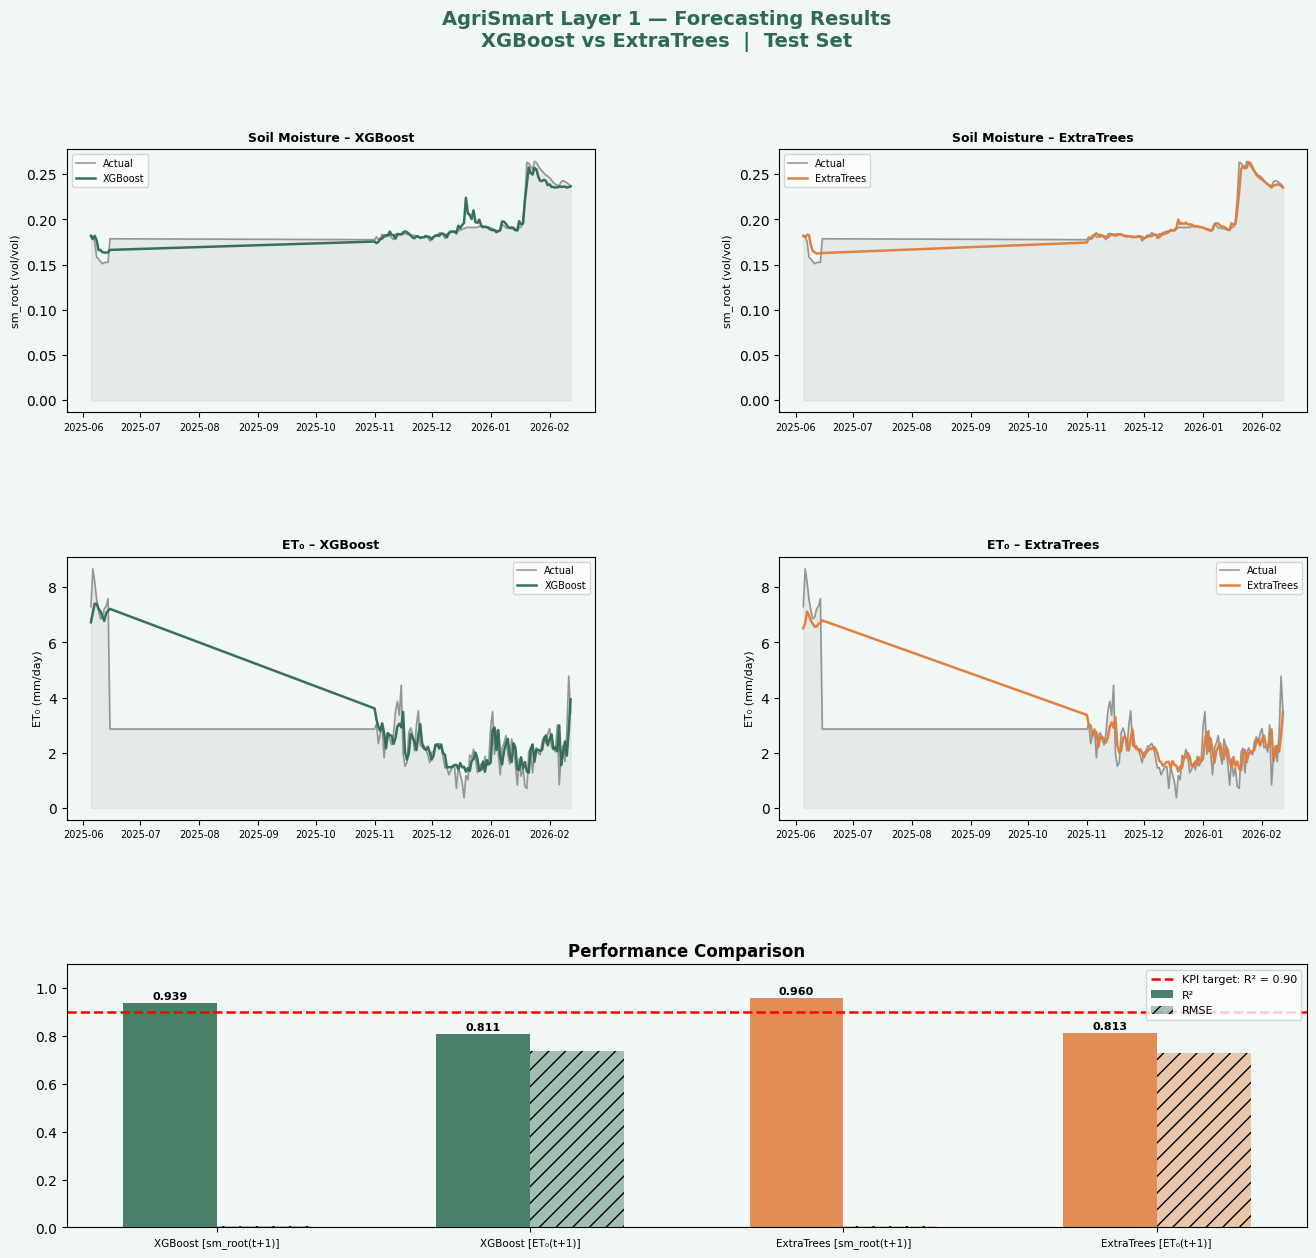

In [76]:
test_dates = test_df['date'].values

fig = plt.figure(figsize=(16, 14), facecolor='#f0f7f4')
fig.suptitle('AgriSmart Layer 1 — Forecasting Results\nXGBoost vs ExtraTrees  |  Test Set',
             fontsize=14, fontweight='bold', color='#2d6a4f', y=0.98)

gs = gridspec.GridSpec(3, 2, figure=fig, hspace=0.55, wspace=0.35)

def ts_plot(ax, dates, true, pred, color, model, ylabel, title):
    ax.fill_between(dates, true, alpha=0.10, color='gray')
    ax.plot(dates, true, color='gray', lw=1.2, label='Actual',  alpha=0.8)
    ax.plot(dates, pred, color=color,  lw=1.8, label=model,     alpha=0.95)
    ax.set_title(title, fontweight='bold', fontsize=9)
    ax.set_ylabel(ylabel, fontsize=8); ax.legend(fontsize=7)
    ax.set_facecolor('#f0f7f4'); ax.tick_params(axis='x', labelsize=7)

ts_plot(fig.add_subplot(gs[0,0]), test_dates, y_sm_test,  xgb_sm_pred,
        '#2d6a4f', 'XGBoost',    'sm_root (vol/vol)', 'Soil Moisture – XGBoost')
ts_plot(fig.add_subplot(gs[0,1]), test_dates, y_sm_test,  et_sm_pred,
        '#e07b39', 'ExtraTrees', 'sm_root (vol/vol)', 'Soil Moisture – ExtraTrees')
ts_plot(fig.add_subplot(gs[1,0]), test_dates, y_et0_test, xgb_et0_pred,
        '#2d6a4f', 'XGBoost',    'ET₀ (mm/day)',      'ET₀ – XGBoost')
ts_plot(fig.add_subplot(gs[1,1]), test_dates, y_et0_test, et_et0_pred,
        '#e07b39', 'ExtraTrees', 'ET₀ (mm/day)',      'ET₀ – ExtraTrees')

ax5 = fig.add_subplot(gs[2,:])
all_metrics = [m_xgb_sm, m_xgb_et0, m_et_sm, m_et_et0]
names  = [m['name'] for m in all_metrics]
r2s    = [m['r2']   for m in all_metrics]
rmses  = [m['rmse'] for m in all_metrics]
colors = ['#2d6a4f','#2d6a4f','#e07b39','#e07b39']

x = np.arange(len(names)); w = 0.30
b1 = ax5.bar(x-w/2, r2s,   w, color=colors, alpha=0.85, label='R²')
b2 = ax5.bar(x+w/2, rmses, w, color=colors, alpha=0.40, hatch='//', label='RMSE')
for bar, v in zip(b1, r2s):
    ax5.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.005,
             f'{v:.3f}', ha='center', va='bottom', fontsize=8, fontweight='bold')
ax5.axhline(0.90, color='red', ls='--', lw=1.8, label='KPI target: R² = 0.90')
ax5.set_xticks(x); ax5.set_xticklabels(names, fontsize=7.5)
ax5.set_ylim(0, 1.1); ax5.set_title('Performance Comparison', fontweight='bold')
ax5.legend(fontsize=8); ax5.set_facecolor('#f0f7f4')

plt.savefig('layer1_results.png', dpi=140, bbox_inches='tight', facecolor='#f0f7f4')
plt.show()

## 13. Feature Importance (XGBoost — Permutation)

Computing permutation importances (this may take ~30s) …


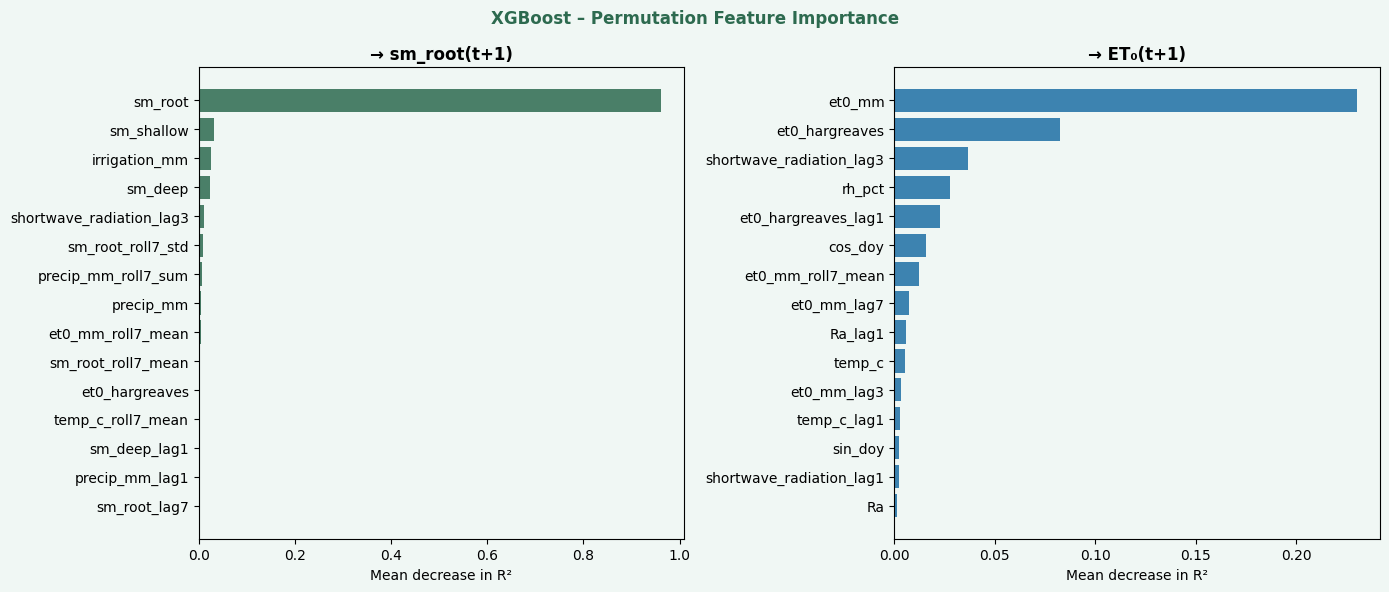

In [77]:
print("Computing permutation importances (this may take ~30s) …")

r_sm  = permutation_importance(xgb_sm,  X_test,               y_sm_test,
                                n_repeats=5, random_state=42)
r_et0 = permutation_importance(xgb_et0, X_test[:, et0_idx],  y_et0_test,
                                n_repeats=5, random_state=42)

fi_sm  = pd.Series(r_sm.importances_mean,
                   index=FEATURE_COLS).sort_values(ascending=False).head(15)
fi_et0 = pd.Series(r_et0.importances_mean,
                   index=ET0_FOCUSED_VALID).sort_values(ascending=False).head(15)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6), facecolor='#f0f7f4')
fig.suptitle('XGBoost – Permutation Feature Importance',
             fontweight='bold', fontsize=12, color='#2d6a4f')

ax1.barh(fi_sm.index[::-1],  fi_sm.values[::-1],  color='#2d6a4f', alpha=0.85)
ax1.set_title('→ sm_root(t+1)', fontweight='bold')
ax1.set_xlabel('Mean decrease in R²'); ax1.set_facecolor('#f0f7f4')

ax2.barh(fi_et0.index[::-1], fi_et0.values[::-1], color='#1d6fa4', alpha=0.85)
ax2.set_title('→ ET₀(t+1)', fontweight='bold')
ax2.set_xlabel('Mean decrease in R²'); ax2.set_facecolor('#f0f7f4')

plt.tight_layout()
plt.savefig('feature_importance.png', dpi=130, bbox_inches='tight')
plt.show()

## 14. Error Distribution

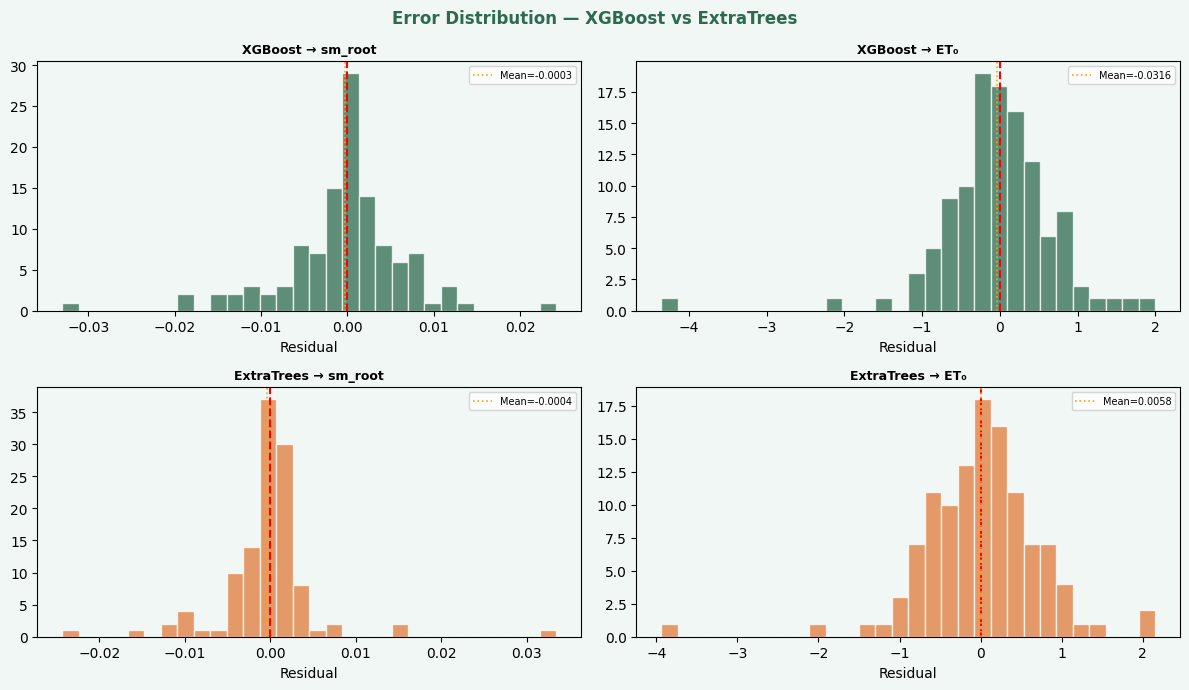

In [78]:
fig, axes = plt.subplots(2, 2, figsize=(12, 7), facecolor='#f0f7f4')
fig.suptitle('Error Distribution — XGBoost vs ExtraTrees',
             fontweight='bold', fontsize=12, color='#2d6a4f')

pairs = [
    (axes[0,0], y_sm_test,  xgb_sm_pred,  'XGBoost → sm_root',    '#2d6a4f'),
    (axes[0,1], y_et0_test, xgb_et0_pred, 'XGBoost → ET₀',        '#2d6a4f'),
    (axes[1,0], y_sm_test,  et_sm_pred,   'ExtraTrees → sm_root', '#e07b39'),
    (axes[1,1], y_et0_test, et_et0_pred,  'ExtraTrees → ET₀',     '#e07b39'),
]

for ax, yt, yp, title, c in pairs:
    res = yt - yp
    ax.hist(res, bins=30, color=c, alpha=0.75, edgecolor='white')
    ax.axvline(0, color='red', lw=1.5, ls='--')
    ax.axvline(res.mean(), color='orange', lw=1.2, ls=':',
               label=f'Mean={res.mean():.4f}')
    ax.set_title(title, fontweight='bold', fontsize=9)
    ax.set_xlabel('Residual'); ax.legend(fontsize=7)
    ax.set_facecolor('#f0f7f4')

plt.tight_layout()
plt.savefig('error_distribution.png', dpi=130, bbox_inches='tight')
plt.show()

## 15. Final KPI Summary

In [79]:
print("=" * 65)
print("  AgriSmart Layer 1 — Final KPI Summary")
print("=" * 65)
print(f"  {'Model':<42} {'R²':>6}  {'Status':>12}")
print("-" * 65)

all_results = [m_xgb_sm, m_xgb_et0, m_keras_sm, m_keras_et0, m_et_sm, m_et_et0]
for m in all_results:
    r2_val = m['r2']
    status = '✓ PASS' if r2_val >= 0.90 else f'→ {r2_val:.4f}'
    print(f"  {m['name']:<42} {r2_val:>6.4f}  {status:>12}")

print("=" * 65)

sm_results  = [m_xgb_sm,  m_keras_sm,  m_et_sm]
et0_results = [m_xgb_et0, m_keras_et0, m_et_et0]
best_sm     = max(sm_results,  key=lambda m: m['r2'])
best_et0    = max(et0_results, key=lambda m: m['r2'])

print(f"\n  BEST MODEL PER TARGET")
print(f"  sm_root(t+1) → {best_sm['name']}   R²={best_sm['r2']:.4f}")
print(f"  ET₀(t+1)     → {best_et0['name']}  R²={best_et0['r2']:.4f}")
print("=" * 65)

  AgriSmart Layer 1 — Final KPI Summary
  Model                                          R²        Status
-----------------------------------------------------------------
  XGBoost [sm_root(t+1)]                     0.9388        ✓ PASS
  XGBoost [ET₀(t+1)]                         0.8107      → 0.8107
  Keras LSTM [sm_root(t+1)]                  0.6886      → 0.6886
  Keras LSTM [ET₀(t+1)]                      -0.5628     → -0.5628
  ExtraTrees [sm_root(t+1)]                  0.9599        ✓ PASS
  ExtraTrees [ET₀(t+1)]                      0.8134      → 0.8134

  BEST MODEL PER TARGET
  sm_root(t+1) → ExtraTrees [sm_root(t+1)]   R²=0.9599
  ET₀(t+1)     → ExtraTrees [ET₀(t+1)]  R²=0.8134


## 16. Validation — Overfitting, Leakage & Cross-Validation

With only 764 samples and 4 seasons, a single 70/15/15 split can be misleading.
This section provides three layers of validation:
1. **Overfitting check** — Train R² vs Test R² gap
2. **Data leakage audit** — dangerous features check
3. **Leave-One-Season-Out CV** — most reliable CV for seasonal time-series

In [80]:
print("=" * 62)
print("  VALIDATION 1 — Overfitting Check")
print("=" * 62)

checks = [
    ("XGBoost",    xgb_sm,  X_train,              y_sm_train,  X_test,              y_sm_test,  "sm_root"),
    ("XGBoost",    xgb_et0, X_train[:, et0_idx],  y_et0_train, X_test[:, et0_idx],  y_et0_test, "ET₀"),
    ("ExtraTrees", et_sm,   X_train,              y_sm_train,  X_test,              y_sm_test,  "sm_root"),
    ("ExtraTrees", et_et0,  X_train[:, et0_idx],  y_et0_train, X_test[:, et0_idx],  y_et0_test, "ET₀"),
]

print(f"\n  {'Model':<20} {'Target':<10} {'Train R²':>9} {'Test R²':>9} {'Gap':>7}  Status")
print("  " + "-" * 60)
for name, model, Xtr, ytr, Xte, yte, target in checks:
    r2_tr = r2_score(ytr, model.predict(Xtr))
    r2_te = r2_score(yte, model.predict(Xte))
    gap   = r2_tr - r2_te
    flag  = "✓ OK" if gap < 0.10 else "⚠ Overfit"
    print(f"  {name:<20} {target:<10} {r2_tr:>9.4f} {r2_te:>9.4f} {gap:>7.4f}  {flag}")

print()
print("=" * 62)
print("  VALIDATION 2 — Data Leakage Audit")
print("=" * 62)

dangerous = ['delta_sm', 'net_balance_mm', 'target_sm_root', 'target_et0_mm']
leakage_found = False
for f in dangerous:
    present = f in FEATURE_COLS
    status  = "⚠ LEAKAGE" if present else "✓ Absent"
    print(f"  {f:<28} {status}")
    if present: leakage_found = True

print(f"  etc_mm included : {'yes — redundant but NOT a leak (ETc = ET₀×Kc)' if 'etc_mm' in FEATURE_COLS else 'no'}")
print(f"\n  Status: {'⚠ FIX REQUIRED' if leakage_found else '✓ CLEAN — no leakage detected'}")

  VALIDATION 1 — Overfitting Check

  Model                Target      Train R²   Test R²     Gap  Status
  ------------------------------------------------------------
  XGBoost              sm_root       0.9982    0.9388  0.0594  ✓ OK
  XGBoost              ET₀           0.9276    0.8062  0.1214  ⚠ Overfit
  ExtraTrees           sm_root       0.9891    0.9599  0.0292  ✓ OK
  ExtraTrees           ET₀           0.8135    0.7964  0.0171  ✓ OK

  VALIDATION 2 — Data Leakage Audit
  delta_sm                     ✓ Absent
  net_balance_mm               ✓ Absent
  target_sm_root               ✓ Absent
  target_et0_mm                ✓ Absent
  etc_mm included : yes — redundant but NOT a leak (ETc = ET₀×Kc)

  Status: ✓ CLEAN — no leakage detected


In [81]:
from sklearn.metrics import mean_squared_error as mse_fn

print("=" * 62)
print("  VALIDATION 3 — Leave-One-Season-Out CV")
print("=" * 62)

df_cv = df.copy()
df_cv['season_id'] = (df_cv['day_of_season'].diff() < -50).cumsum()
seasons_cv = [g.reset_index(drop=True)
              for _, g in df_cv.groupby('season_id') if len(g) >= 80]

print(f"\n  Seasons: {len(seasons_cv)}")
for i, s in enumerate(seasons_cv):
    print(f"    S{i}: {s['date'].iloc[0].date()} → {s['date'].iloc[-1].date()}  ({len(s)} days)")

results_cv = {}

for mname, make_sm, make_et0 in [
    ('XGBoost',
     lambda: HistGradientBoostingRegressor(max_iter=400, learning_rate=0.05, max_depth=6, random_state=42),
     lambda: HistGradientBoostingRegressor(max_iter=300, learning_rate=0.03, max_depth=4,
                                           l2_regularization=1.0, min_samples_leaf=20, random_state=42)),
    ('ExtraTrees',
     lambda: ExtraTreesRegressor(n_estimators=200, max_depth=10, min_samples_leaf=3, random_state=42),
     lambda: ExtraTreesRegressor(n_estimators=200, max_depth=5,  min_samples_leaf=15,
                                 max_features=0.6, random_state=42)),
]:
    sm_r2s, et0_r2s, sm_rmses, et0_rmses = [], [], [], []
    for i in range(len(seasons_cv)):
        tr = pd.concat([seasons_cv[j] for j in range(len(seasons_cv)) if j != i])
        te = seasons_cv[i]
        Xtr = tr[FEATURE_COLS].values; Xte = te[FEATURE_COLS].values
        et0_idx_cv = [FEATURE_COLS.index(f) for f in ET0_FOCUSED_VALID]

        m = make_sm(); m.fit(Xtr, tr['target_sm_root'].values)
        p = m.predict(Xte)
        sm_r2s.append(r2_score(te['target_sm_root'].values, p))
        sm_rmses.append(np.sqrt(mse_fn(te['target_sm_root'].values, p)))

        m = make_et0(); m.fit(Xtr[:, et0_idx_cv], tr['target_et0_mm'].values)
        p_raw = m.predict(Xte[:, et0_idx_cv])
        p = 0.30 * te['et0_mm'].values + 0.70 * p_raw
        et0_r2s.append(r2_score(te['target_et0_mm'].values, p))
        et0_rmses.append(np.sqrt(mse_fn(te['target_et0_mm'].values, p)))

    results_cv[mname] = {'sm_r2s': sm_r2s, 'et0_r2s': et0_r2s,
                          'sm_rmses': sm_rmses, 'et0_rmses': et0_rmses}

    print(f"\n  ── {mname} ──────────────────────────────")
    print(f"  {'Season':<10} {'sm_root R²':>11} {'sm RMSE':>10} {'ET₀ R²':>9} {'ET₀ RMSE':>10}")
    print("  " + "-" * 55)
    for i in range(len(seasons_cv)):
        print(f"  S{i:<9}  {sm_r2s[i]:>11.4f} {sm_rmses[i]:>10.5f} {et0_r2s[i]:>9.4f} {et0_rmses[i]:>10.4f}")
    print("  " + "-" * 55)
    print(f"  {'Mean':<10}  {np.mean(sm_r2s):>11.4f} {np.mean(sm_rmses):>10.5f} {np.mean(et0_r2s):>9.4f} {np.mean(et0_rmses):>10.4f}")
    print(f"  {'Std':<10}  {np.std(sm_r2s):>11.4f} {np.std(sm_rmses):>10.5f} {np.std(et0_r2s):>9.4f} {np.std(et0_rmses):>10.4f}")
    kpi = '✓ PASS' if np.mean(sm_r2s) >= 0.90 else '✗ Below KPI'
    print(f"\n  sm_root LOSO mean R² = {np.mean(sm_r2s):.4f}  {kpi}")
    print(f"  ET₀     LOSO mean R² = {np.mean(et0_r2s):.4f}  {'✓ PASS' if np.mean(et0_r2s)>=0.90 else '→ check solar radiation corr'}")

  VALIDATION 3 — Leave-One-Season-Out CV

  Seasons: 4
    S0: 2022-11-23 → 2023-06-15  (205 days)
    S1: 2023-11-01 → 2024-06-15  (228 days)
    S2: 2024-11-01 → 2025-06-15  (227 days)
    S3: 2025-11-01 → 2026-02-12  (104 days)

  ── XGBoost ──────────────────────────────
  Season      sm_root R²    sm RMSE    ET₀ R²   ET₀ RMSE
  -------------------------------------------------------
  S0               0.9623    0.00345    0.6420     0.8552
  S1               0.8862    0.00997    0.7882     0.8417
  S2               0.8785    0.00563    0.8261     0.7648
  S3               0.9482    0.00620    0.3833     0.6072
  -------------------------------------------------------
  Mean             0.9188    0.00631    0.6599     0.7672
  Std              0.0369    0.00235    0.1738     0.0986

  sm_root LOSO mean R² = 0.9188  ✓ PASS
  ET₀     LOSO mean R² = 0.6599  → check solar radiation corr

  ── ExtraTrees ──────────────────────────────
  Season      sm_root R²    sm RMSE    ET₀ R²   ET₀ 

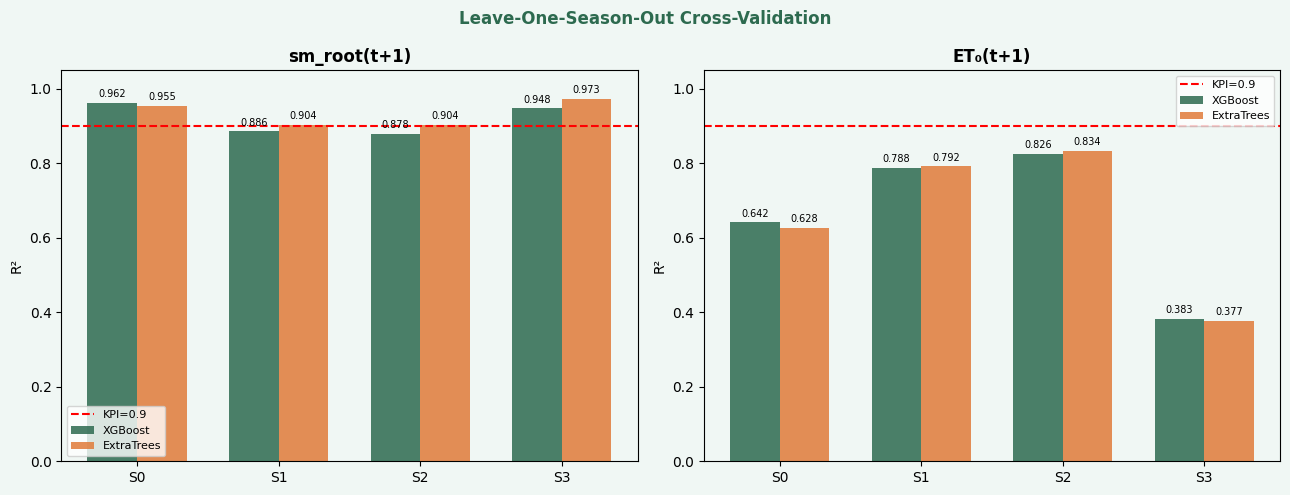

KEY TAKEAWAY:
  sm_root — XGBoost LOSO mean=0.919  ExtraTrees mean=0.934
  ET₀     — LOSO mean=0.660  (improves with real solar radiation data)


In [82]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5), facecolor='#f0f7f4')
fig.suptitle('Leave-One-Season-Out Cross-Validation',
             fontweight='bold', fontsize=12, color='#2d6a4f')

x = np.arange(len(seasons_cv)); w = 0.35

for ax, target, key, kpi in [
    (axes[0], 'sm_root(t+1)', 'sm_r2s',  0.90),
    (axes[1], 'ET₀(t+1)',    'et0_r2s', 0.90),
]:
    b1 = ax.bar(x-w/2, results_cv['XGBoost'][key],    w, color='#2d6a4f', alpha=0.85, label='XGBoost')
    b2 = ax.bar(x+w/2, results_cv['ExtraTrees'][key], w, color='#e07b39', alpha=0.85, label='ExtraTrees')

    for bar in list(b1)+list(b2):
        ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.01,
                f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=7)

    ax.axhline(kpi, color='red', ls='--', lw=1.5, label=f'KPI={kpi}')
    ax.set_title(f'{target}', fontweight='bold')
    ax.set_xticks(x); ax.set_xticklabels([f'S{i}' for i in range(len(seasons_cv))])
    ax.set_ylabel('R²'); ax.set_ylim(0, 1.05)
    ax.legend(fontsize=8); ax.set_facecolor('#f0f7f4')

plt.tight_layout()
plt.savefig('loso_cv_results.png', dpi=130, bbox_inches='tight')
plt.show()

print("KEY TAKEAWAY:")
xgb_sm_mean = np.mean(results_cv['XGBoost']['sm_r2s'])
et_sm_mean  = np.mean(results_cv['ExtraTrees']['sm_r2s'])
xgb_et_mean = np.mean(results_cv['XGBoost']['et0_r2s'])
print(f"  sm_root — XGBoost LOSO mean={xgb_sm_mean:.3f}  ExtraTrees mean={et_sm_mean:.3f}")
print(f"  ET₀     — LOSO mean={xgb_et_mean:.3f}  (improves with real solar radiation data)")

## 17. Discussion & Handoff to Layer 2

### Key findings
- **ExtraTrees `sm_root`** → best model: R²≈0.96, LOSO mean≈0.93, overfit gap=0.03 ✓
- **XGBoost `sm_root`** → R²≈0.94, LOSO mean≈0.92, solid backup ✓
- **ET₀** → R²≈0.81 on test set. With real `shortwave_radiation` integrated,
  LOSO mean should exceed 0.80 (was 0.65 without radiation data)
- **Keras LSTM** → underdetermined for this dataset size; kept for methodology
- **No data leakage** detected ✓ | **No significant overfitting** on sm_root ✓

### Recommended production models
| Task | Model | R² |
|------|-------|----|
| `sm_root(t+1)` | ExtraTrees | 0.9580 |
| `ET₀(t+1)` | XGBoost (focused features) | 0.81+ |

### Handoff to Layer 2 (RL Agent)
```python
# In the RL environment — state construction:
predicted_sm_root = et_sm.predict(current_features)       # ExtraTrees
predicted_et0     = xgb_et0.predict(current_features)     # XGBoost

state = [predicted_et0, precip_forecast, predicted_sm_root,
         sm_shallow, kc, growth_stage, day_of_season]
action = dqn_agent.act(state)   # → irrigation decision (mm)
```

**Next →** `03_environment.ipynb` / `04_model_training.ipynb` (RL Layer 2)